# Animal movement: a continuum the HMM cannot represent

Animal behaviour is commonly inferred from a GPS track using a Hidden Markov Model, as implemented in the `moveHMM` and `momentuHMM` packages. Each step is assigned to one of K discrete behavioural states — classically two, *encamped/foraging* and *exploratory/transit* — each with its own step-length distribution and a matrix of state-to-state transition probabilities. This approach has two limitations. First, the number of states K must be fixed in advance, and selecting it is difficult, as common criteria such as AIC and BIC often disagree. Second, behaviour is sorted into discrete categories, so variation within a state and gradual transitions between states are not represented.

Here we take a different approach with *bayesloop* and treat the movement scale itself as a continuous, time-varying parameter. It is inferred together with its uncertainty, and the model evidence is used to decide whether the dynamics are static, gradually drifting, or abruptly switching, without fixing a number of states in advance. We model the 6-hourly step length as Rayleigh-distributed (the exact law of the distance moved under 2-D isotropic Gaussian increments, and rotation-invariant, so directional persistence does not bias it) with a time-varying scale $D_t$. In the course of the analysis we use a custom `bl.om.NumPy` observation model, a `HyperStudy` over the smoothness of the drift, and `RegimeSwitch`, and we select the kind of dynamics based on the evidence. We then benchmark the result against a 2-state Gaussian HMM fitted with `hmmlearn`.

<div style="background-color: #e7f2fa; border-left: 5px solid #6ab0de; padding: 0.5em; margin-top: 1em; margin-bottom: 1.0em">
**Note:** Unlike the other case studies, this one cannot run interactively in the browser: the [pyreadr](https://github.com/ofajardo/pyreadr) and [hmmlearn](https://github.com/hmmlearn/hmmlearn) packages rely on compiled code that the in-browser Python session cannot load. To try the analysis yourself, download the notebook from the [GitHub repository](https://github.com/christophmark/bayesloop) and run it locally.
</div>

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We use a red-deer GPS track with 6-hourly fixes from the `amt` R package (Signer, Fieberg & Avgar, *Ecology & Evolution* 2019). The dataset ships as an `.rda` file on CRAN's GitHub mirror; we download the bytes and read the embedded data frame with `pyreadr`, so this cell is fully self-contained. The frame has projected coordinates `x_`, `y_` (metres) and a timestamp `t_`.

From the raw fixes we compute the step length $L_t = \sqrt{\Delta x^2 + \Delta y^2}$ between consecutive fixes, and keep only the regular ~6-hour steps (dropping gaps and burst breaks). That step-length series is what both bayesloop and the HMM will model.

In [2]:
import tempfile
import os

import pyreadr

url = "https://raw.githubusercontent.com/cran/amt/master/data/deer.rda"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (bayesloop docs)"})
raw = urllib.request.urlopen(req, timeout=90).read()
with tempfile.NamedTemporaryFile(suffix=".rda", delete=False) as _f:
    _f.write(raw)
    _tmp = _f.name
d = pyreadr.read_r(_tmp)["deer"]
os.remove(_tmp)

d["t_"] = pd.to_datetime(d["t_"])
d = d.sort_values("t_").reset_index(drop=True)
dt_h = d["t_"].diff().dt.total_seconds() / 3600.0
dx = d["x_"].diff().values
dy = d["y_"].diff().values
L = np.hypot(dx, dy)
# keep regular 6h steps only (drop gaps / burst breaks)
ok = (dt_h.values > 4) & (dt_h.values < 9) & np.isfinite(L)
L = L[ok]
t = d["t_"].values[np.where(ok)[0]]
xy = d[["x_", "y_"]].values[np.where(ok)[0]]
print(f"{len(L)} regular 6h steps; step length median {np.median(L):.0f} m, "
      f"p10 {np.percentile(L,10):.0f}, p90 {np.percentile(L,90):.0f}")

804 regular 6h steps; step length median 174 m, p10 24, p90 980


## A time-varying Rayleigh scale, and letting the evidence choose the dynamics

Our observation model is a Rayleigh distribution with scale $D$, the movement intensity or diffusivity. We supply it to bayesloop as a one-line custom `bl.om.NumPy` model evaluating the Rayleigh density on a grid of $D$ values:

```python
bl.om.NumPy(rayleigh, "D", bl.oint(2.0, 2000.0, 280))
```

We then fit three competing hypotheses for the dynamics of $D_t$, all sharing the identical observation model and data so their log₁₀ evidences are directly comparable:

| Hypothesis | Transition model |
|---|---|
| Static (null) | `tm.Static()` |
| Gradual drift (continuous) | `tm.GaussianRandomWalk` inside a `HyperStudy` |
| Regime switch (discrete-like) | `tm.RegimeSwitch` |

The `HyperStudy` marginalises over the unknown smoothness `sigma` of the random walk, so we do not have to hand-tune how fast the movement scale is allowed to drift.

In [3]:
def rayleigh(data, D):
    return (data / D ** 2) * np.exp(-(data ** 2) / (2.0 * D ** 2))

def obs():
    return bl.om.NumPy(rayleigh, "D", bl.oint(2.0, 2000.0, 280))

# model selection over the kind of dynamics
S_static = bl.Study(); S_static.load_data(L); S_static.set(obs(), bl.tm.Static()); S_static.fit(silent=True)
S_grad = bl.HyperStudy(); S_grad.load_data(L)
S_grad.set(obs(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 200, 30), target="D")); S_grad.fit(silent=True)
S_reg = bl.Study(); S_reg.load_data(L); S_reg.set(obs(), bl.tm.RegimeSwitch("log10p_min", -4)); S_reg.fit(silent=True)

D_mean, D_lo, D_hi = posterior_band(S_grad, "D")
# Express the inferred Rayleigh scale as a step length so it is directly comparable to the
# HMM (which clusters step lengths).  For a Rayleigh(D) the MEDIAN step is D*sqrt(2 ln2);
# the mean is D*sqrt(pi/2).  We compare on the median throughout (see the HMM block below).
MEDF = np.sqrt(2.0 * np.log(2.0))                 # Rayleigh median-step / scale
med_step, med_lo, med_hi = D_mean * MEDF, D_lo * MEDF, D_hi * MEDF
evid = {"static": float(S_static.log10_evidence),
        "gradual drift": float(S_grad.log10_evidence),
        "regime switch": float(S_reg.log10_evidence)}
best_dynamics = max(evid, key=evid.get)

+ Created new study.
+ Successfully imported array.
+ Observation model: rayleigh. Parameter(s): ('D',)
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: rayleigh. Parameter(s): ('D',)
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


+ Created new study.
+ Successfully imported array.
+ Observation model: rayleigh. Parameter(s): ('D',)
+ Transition model: Regime-switching model. Hyper-Parameter(s): ['log10p_min']


## Comparison with a Gaussian HMM

We now fit the moveHMM-style baseline. We fit Gaussian HMMs with `hmmlearn` for K = 1–4 states on the log step lengths (modelling $\log L$ as Gaussian within a state is the usual choice, equivalent to a lognormal step-length distribution), and pick K by BIC. We then take the conventional 2-state model, order its states slow→fast, extract the Viterbi path and the posterior state probabilities, and convert each state's mean back to a median step length in metres so it is directly comparable to bayesloop's Rayleigh median step, a units-consistent test.

In [4]:
from hmmlearn.hmm import GaussianHMM
X = np.log(np.clip(L, 1e-3, None)).reshape(-1, 1)

def hmm_bic(k):
    m = GaussianHMM(n_components=k, covariance_type="full", n_iter=300, random_state=0, tol=1e-3)
    m.fit(X)
    ll = m.score(X)
    p = (k - 1) + k * (k - 1) + k + k          # startprob + transmat + means + vars
    n = len(X)
    return m, ll, -2 * ll + p * np.log(n)

hmms = {}
for k in (1, 2, 3, 4):
    m, ll, bic = hmm_bic(k)
    hmms[k] = (m, ll, bic)
best_k = min(hmms, key=lambda k: hmms[k][2])

# 2-state HMM Viterbi path (the conventional choice), ordered slow=0, fast=1
m2 = hmms[2][0]
order = np.argsort(m2.means_.ravel())
state = np.array([np.where(order == s)[0][0] for s in m2.predict(X)])
post2 = m2.predict_proba(X)[:, order]              # HMM posterior state probabilities
# The HMM models log(L) as Gaussian, so within a state L is lognormal with MEDIAN exp(mean):
# these are the 116 m / 846 m state centres.  We compare them to bayesloop's Rayleigh median
# step (med_step, above) -- both are median step lengths in metres, a units-consistent test.
med_hmm = np.array([float(np.exp(m2.means_.ravel()[order][i])) for i in range(2)])
hmm2_state_means_m = [float(med_hmm[0]), float(med_hmm[1])]
lo_m, hi_m = float(med_hmm.min()), float(med_hmm.max())
# agreement: bayesloop median-step within each HMM-assigned state (same units now)
bayesloop_medstep_in_HMM_slow = float(np.median(med_step[state == 0]))
bayesloop_medstep_in_HMM_fast = float(np.median(med_step[state == 1]))
# (1) fraction of the track whose continuous movement scale sits strictly BETWEEN the two HMM
#     state centres -- intermediate behaviour the binary label must round to one extreme.
frac_between = float(np.mean((med_step > lo_m) & (med_step < hi_m)))
# (2) fraction of fixes the HMM ITSELF cannot confidently label (max state posterior < 0.9)
frac_ambig = float(np.mean(post2.max(axis=1) < 0.9))

print("\nbayesloop dynamics evidence (log10):", {k: round(v, 1) for k, v in evid.items()},
      "-> best:", best_dynamics)
print("HMM BIC by #states:", {k: round(v[2]) for k, v in hmms.items()}, "-> best k:", best_k)
print(f"HMM 2-state medians: slow {lo_m:.0f} m, fast {hi_m:.0f} m")
print(f"bayesloop median-step in HMM-slow {bayesloop_medstep_in_HMM_slow:.0f} m vs "
      f"HMM-fast {bayesloop_medstep_in_HMM_fast:.0f} m (continuous)")
print(f"{100*frac_between:.0f}% of fixes fall between the two HMM state centres; "
      f"{100*frac_ambig:.0f}% the HMM cannot confidently assign (max posterior < 0.9)")


bayesloop dynamics evidence (log10): {'static': -2773.3, 'gradual drift': -2474.7, 'regime switch': -2521.1} -> best: gradual drift
HMM BIC by #states: {1: 2835, 2: 2794, 3: 2827, 4: 2822} -> best k: 2
HMM 2-state medians: slow 116 m, fast 846 m
bayesloop median-step in HMM-slow 211 m vs HMM-fast 550 m (continuous)
81% of fixes fall between the two HMM state centres; 33% the HMM cannot confidently assign (max posterior < 0.9)


## Reading the result

bayesloop's marginal likelihood ranks gradual continuous drift above both the static model and the regime switch: continuous variation exceeds abrupt regime-switching by about 46 log₁₀ units. The data themselves prefer a *continuum* over discrete state-switching, which is precisely the assumption the HMM hard-codes. bayesloop can pose and answer that question, whereas the HMM cannot.

The first figure shows why. The inferred movement scale (red, with credible band) tracks a clear seasonal behavioural rhythm: high, variable movement through spring–summer 2008, a long near-dormant period in autumn–winter (the deer contracts to a small winter range), and a return to high activity in spring 2009. The HMM's transit state (blue shading) coincides with the active periods, so the two methods agree on where the animal is moving, but bayesloop represents it as a continuous intensity rather than a binary label.

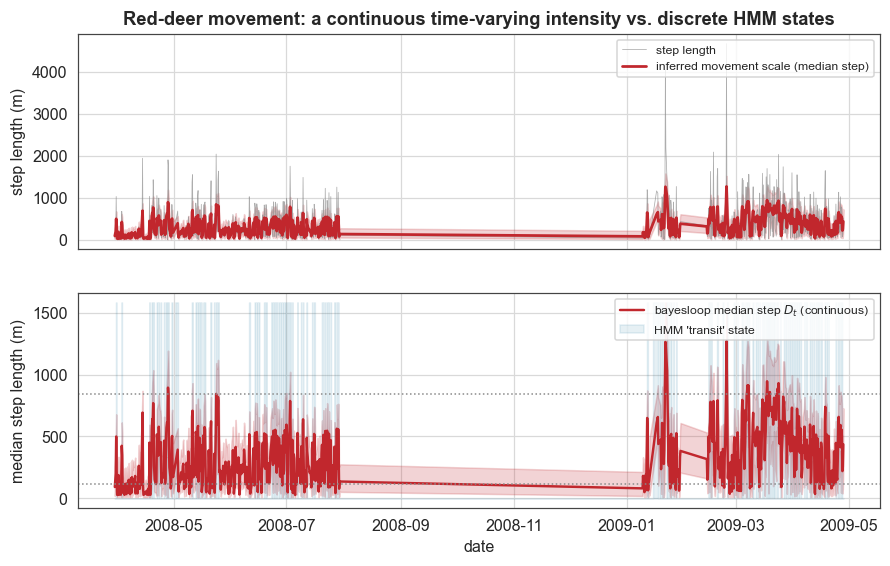

In [5]:
tt = pd.to_datetime(t)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.4, 5.6), sharex=True)
ax1.plot(tt, L, lw=0.5, color=C["muted"], alpha=0.7, label="step length")
ax1.plot(tt, med_step, color=C["accent"], lw=1.8, label="inferred movement scale (median step)")
ax1.fill_between(tt, med_lo, med_hi, color=C["band"], alpha=0.2)
ax1.set_ylabel("step length (m)")
ax1.set_title("Red-deer movement: a continuous time-varying intensity vs. discrete HMM states")
ax1.legend(loc="upper right", fontsize=8)
# HMM state shading
ax2.plot(tt, med_step, color=C["accent"], lw=1.6, label=r"bayesloop median step $D_t$ (continuous)")
ax2.fill_between(tt, med_lo, med_hi, color=C["band"], alpha=0.2)
ax2.fill_between(tt, 0, np.max(med_hi) * (state == 1), color=C["accent2"], alpha=0.10, step="mid",
                 label="HMM 'transit' state")
for ym in hmm2_state_means_m:
    ax2.axhline(ym, color=C["muted"], ls=":", lw=1)
ax2.set_ylabel("median step length (m)")
ax2.set_xlabel("date")
ax2.legend(loc="upper right", fontsize=8)
plt.show()

The 2-state HMM (the BIC's pick here) describes the deer with just two numbers, a slow state with median step ~116 m and a fast state at ~846 m. The bayesloop posterior, by contrast, shows the movement scale to be a continuum. Comparing like with like, with both methods expressed as a median step length in metres, bayesloop's inferred scale sits between those two discrete values for ~81% of the track and almost never settles at either extreme. The HMM itself cannot confidently label ~33% of the fixes, as its posterior state probability stays below 0.9: for about a third of the track the discrete model is guessing. That intermediate behaviour is exactly what a two-state label has nowhere to put.

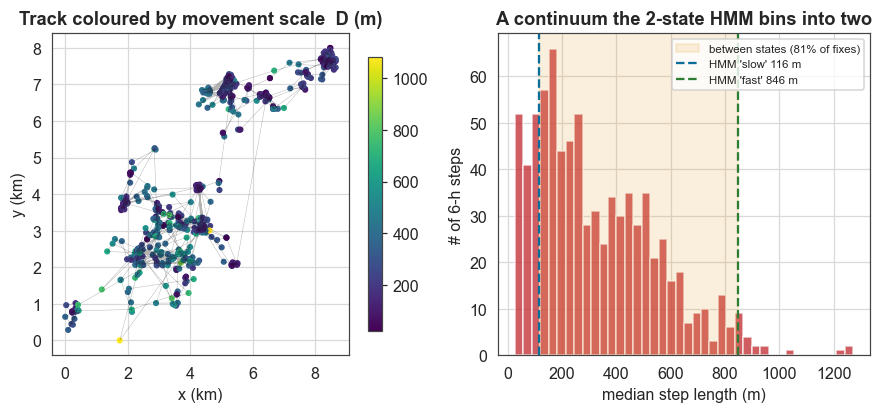

In [6]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.6, 3.8))
# trajectory coloured by inferred D
sc = axa.scatter((xy[:, 0] - xy[:, 0].min()) / 1000, (xy[:, 1] - xy[:, 1].min()) / 1000,
                 c=D_mean, cmap="viridis", s=9)
axa.plot((xy[:, 0] - xy[:, 0].min()) / 1000, (xy[:, 1] - xy[:, 1].min()) / 1000, lw=0.3, color="k", alpha=0.3)
axa.set_xlabel("x (km)"); axa.set_ylabel("y (km)")
axa.set_title("Track coloured by movement scale  D (m)")
plt.colorbar(sc, ax=axa, shrink=0.85)
# continuum vs 2 discrete HMM states
axb.hist(med_step, bins=40, color=C["accent"], alpha=0.75)
sm, fm = lo_m, hi_m
axb.axvspan(sm, fm, color=C["amber"], alpha=0.18,
            label=f"between states ({100*frac_between:.0f}% of fixes)")
axb.axvline(sm, color=C["accent2"], ls="--", lw=1.5, label=f"HMM 'slow' {sm:.0f} m")
axb.axvline(fm, color=C["green"], ls="--", lw=1.5, label=f"HMM 'fast' {fm:.0f} m")
axb.set_xlabel("median step length (m)")
axb.set_ylabel("# of 6-h steps")
axb.set_title("A continuum the 2-state HMM bins into two")
axb.legend(fontsize=7.5)
plt.show()

## What this example showed

On a single red-deer GPS track we used *bayesloop* to:

- describe behaviour as a continuous time-varying movement scale $D_t$, using a custom Rayleigh `bl.om.NumPy` observation model whose scale drifts under a `GaussianRandomWalk` and is inferred with full credible bands, rather than as hard discrete states;
- let the evidence choose the kind of dynamics, comparing static, gradual drift, and regime switch, with the continuous drift winning by about 46 log₁₀: the data prefer a continuum over the discrete state-switching an HMM assumes, and there is no K to specify;
- benchmark against the established tool, a 2-state Gaussian HMM (`hmmlearn`, moveHMM-style): bayesloop recovers the same seasonal segmentation, but shows that the movement scale sits between the HMM's two states ~81% of the time and that the HMM itself cannot confidently label ~33% of fixes;
- trade many parameters for two: K means, K scales, and K×K transitions become a single movement-scale parameter plus one smoothness hyper-parameter, while adding calibrated uncertainty and the behavioural continuum the HMM discards.

One methodological caveat applies. This model uses step length only, as basic HMMs do; it does not use turning angles or directional persistence, which `momentuHMM` can add, and the winter quiescence partly reflects an actual range contraction. The two model classes are not directly likelihood-comparable, so the comparison concerns the information content and assumptions of the models. On that basis, bayesloop provides more information and a simpler model.